# 이미지 분류 실습(CNN X)

In [ ]:
import matplotlib.pyplot as plt 
from torchvision.datasets.mnist import MNIST # 숫자 손글씨 데이터셋
from torchvision.transforms import ToTensor # transforms -> 이미지를 전처리해주는데 사용
from torch.utils.data.dataloader import DataLoader # train_test_split과 거의 같은 역할 mini-batch을 생성
import torch.nn as nn
from torch.optim.adam import Adam
import torch

In [ ]:
train_data = MNIST(root='./', train=True, download=True, transform=ToTensor())
test_data = MNIST(root='./', train=False, download=True, transform=ToTensor())

100.0%
100.0%
100.0%
100.0%


In [5]:
train_data.data.size()
train_data.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [8]:
train_data.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

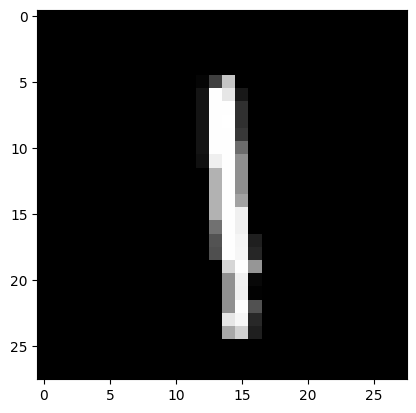

In [13]:
plt.imshow(train_data.data[8], cmap='gray')

In [15]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [17]:
next(iter(train_loader))[0].shape

torch.Size([32, 1, 28, 28])

In [33]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = nn.Sequential(
    nn.Linear(28*28, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

model.to(device)

Sequential(
  (0): Linear(in_features=784, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

In [34]:
next(iter(train_loader))[1]

tensor([7, 9, 9, 9, 5, 5, 8, 2, 4, 0, 4, 2, 5, 8, 8, 3, 3, 7, 8, 0, 6, 3, 3, 4,
        6, 9, 4, 6, 1, 3, 2, 7])

In [35]:
from tensorboardX import SummaryWriter
writer = SummaryWriter()
lr = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=lr)
epochs = 20

step = 0
for epoch in range(epochs):
    for data, label in train_loader: # [(데이터, 정답), (데이터, 정답), (데이터, 정답)...]
        # 최적화 함수 초기화
        optimizer.zero_grad()

        flatten_data = torch.reshape(data, (-1, 28*28))
        # flatten_data = data.view(-1, 28*28)
        pred = model(flatten_data.to(device))
        loss = criterion(pred, label.to(device))
        writer.add_scalar('Loss/train', loss.item(), step )
        step += 1
        loss.backward()
        optimizer.step()
    
    print(f'{epoch + 1} : {loss.item()}')




1 : 0.05453254282474518
2 : 0.019645843654870987
3 : 0.12612856924533844
4 : 0.018841532990336418
5 : 0.006801397539675236
6 : 0.16909167170524597
7 : 0.0032480591908097267
8 : 0.009310481138527393
9 : 0.005167640745639801
10 : 0.0012852160725742579
11 : 0.007313375361263752
12 : 0.016650410369038582
13 : 0.0005498055252246559
14 : 0.22704358398914337
15 : 0.04197192192077637
16 : 0.04257793724536896
17 : 0.0008972315117716789
18 : 0.0009028069907799363
19 : 2.9795892260153778e-05
20 : 0.029514387249946594


In [48]:
model.eval()

with torch.no_grad():
    total_corr = 0

    for images, labels in test_loader:

        #print(images.shape)
        images = images.view(-1, 28*28).to(device)
        labels = labels.to(device)

        preds = model(images)

        _, pred = torch.max(preds.data, 1)
        total_corr = total_corr + (pred == labels).sum().item()

print(f"정확도: {total_corr / len(test_data.targets)}")
        


정확도: 0.9767


In [45]:
pred

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6], device='cuda:0')

In [47]:
sum(labels == pred) ## 정답인지 확인

tensor(16, device='cuda:0')

In [43]:
pred.data[0]

tensor([-18.2864,  14.2922,  -4.6247,  -6.4710, -11.9610, -21.4729, -13.8320,
          1.2137,  -5.0806, -13.9192], device='cuda:0')

In [41]:
torch.Size([16, 10])

torch.Size([16, 10])

In [40]:
_, pred = torch.max(pred.data, 1)
pred

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6], device='cuda:0')